## Metrics Evaluation Lab

Throughout your early career as a Data Scientist you've spent most your time cleaning data, but now you are starting to build models and have come to realize the most important part about understanding any machine learning model (or any model, really) is understanding its weakness and vulnerabilities.

In doing so you've decided to practice on a dataset about mushrooms, because after all if you don't know how to evaluate a model thoroughly you'll be in real **truffle** (ha...ha) and introduce a approach that is new to you. 

Below I've build an initial **Decision Tree** model on the mushroom dataset to get you started. Think of the Decision Tree as your field guide – splitting mushrooms into categories one feature at a time. 

### Part 1: Load and Clean

Using the [mushroom dataset](https://archive.ics.uci.edu/static/public/848/secondary+mushroom+dataset.zip) and the documentation below answer the provided question. 

- [Mushroom Documentation](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset)

*How well can we predict whether a mushroom is poisonous or edible based on its physical characteristics?* 

### Part 2: Build the model

This will most be provided for you, but some details you'll need to code yourself. 

### Part 3: Evaluate and assess

Consider where classification errors are occurring, is there a pattern? If so discuss this pattern and why you think this is the case. Use the confusion matrix to determine the pattern. 

### Keys to Success

- Using the evaluation metrics correctly: we are focusing on classification not regression
- Evaluation is not about the metrics per se, but what they mean; speaking through your question in light of the evaluation metrics is the primary objective of this lab. Think of yourself as a "model detective" that works to leave no stone unturned!
- Remember, be patient and double check your code or you might find yourself in real **shiitake** :)

---
## Initial Decision Tree Model – Starter Code

The code below walks you through an initial Decision Tree classifier on the mushroom dataset. Use it as a *spore*-ing board (sorry, not sorry) to complete the lab.

### Step 1 – Imports

In [2]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn import metrics

### Step 2 – Load the Mushroom Dataset

We load the mushroom dataset directly. The target column is `type` (poisonous **p** vs edible **e**). 

For the full lab you may want to use the secondary mushroom dataset from UCI:
- [Download](https://archive.ics.uci.edu/static/public/848/secondary+mushroom+dataset.zip)
- [Documentation](https://archive.ics.uci.edu/dataset/848/secondary+mushroom+dataset)

In [3]:
# Load the mushroom dataset
mushroom_url = (
    "https://raw.githubusercontent.com/stedy/"
    "Machine-Learning-with-R-datasets/master/mushrooms.csv"
)

mushroom_data = pd.read_csv(mushroom_url)

print(f'Dataset shape: {mushroom_data.shape}')
mushroom_data.head()

Dataset shape: (8124, 23)


,type,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Step 3 – Explore the Data

In [4]:
# Use the various exploration methods we covered in class to understand the dataset.
# This tells us whether the variables are stored as objects (categorical text) or numbers
print(mushroom_data.dtypes)


type                        str
cap_shape                   str
cap_surface                 str
cap_color                   str
bruises                     str
odor                        str
gill_attachment             str
gill_spacing                str
gill_size                   str
gill_color                  str
stalk_shape                 str
stalk_root                  str
stalk_surface_above_ring    str
stalk_surface_below_ring    str
stalk_color_above_ring      str
stalk_color_below_ring      str
veil_type                   str
veil_color                  str
ring_number                 str
ring_type                   str
spore_print_color           str
population                  str
habitat                     str
dtype: object


In [5]:
print('---')
print(mushroom_data.describe())

---
        type cap_shape cap_surface cap_color bruises  odor gill_attachment  \
count   8124      8124        8124      8124    8124  8124            8124   
unique     2         6           4        10       2     9               2   
top        e         x           y         n       f     n               f   
freq    4208      3656        3244      2284    4748  3528            7914   

       gill_spacing gill_size gill_color  ... stalk_surface_below_ring  \
count          8124      8124       8124  ...                     8124   
unique            2         2         12  ...                        4   
top               c         b          b  ...                        s   
freq           6812      5612       1728  ...                     4936   

       stalk_color_above_ring stalk_color_below_ring veil_type veil_color  \
count                    8124                   8124      8124       8124   
unique                      9                      9         1          4   
top

In [6]:
# Check for missing values
print(mushroom_data.isnull().sum())

type                        0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
dtype: int64


### Step 4 – Clean & Prepare the Data



In [7]:
# Drop rows with missing values 
mushroom_data = mushroom_data.dropna()
print(f'Rows after cleaning: {len(mushroom_data)}')

Rows after cleaning: 8124


In [8]:
# Separate features (X) and target (y)
# Our target is 'type' – predicting poisonous (p) vs edible (e)
y = mushroom_data['type']
X = mushroom_data.drop('type', axis=1).copy()

In [9]:
# Calculate prevalence – how common is each class?
# This tells us what accuracy we'd get if we just guessed the majority class every time.
# If our model can't beat the prevalence, it's about as useful as a chocolate teapot...
# or a poisonous mushroom at a dinner party 

prevalence = y.value_counts(normalize=True)
print('Class prevalence (baseline):')
print(prevalence)
print(f'\nMajority class baseline accuracy: {prevalence.max():.4f}')

Class prevalence (baseline):
type
e    0.517971
p    0.482029
Name: proportion, dtype: float64

Majority class baseline accuracy: 0.5180


About 51.8% of mushrooms are edible and 48.2% are poisonous.
This means the dataset is fairly balanced (close to 50/50).

The majority class baseline accuracy is 0.5180,
which means if we always guessed "edible",
we would be correct about 51.8% of the time.

Therefore, our model must perform significantly better than 0.5180
to be considered useful.

In [10]:
# 4. Check number of unique levels
# This helps us understand how many categories each feature has
# and whether any features might have too many rare values

print(X.nunique())

cap_shape                    6
cap_surface                  4
cap_color                   10
bruises                      2
odor                         9
gill_attachment              2
gill_spacing                 2
gill_size                    2
gill_color                  12
stalk_shape                  2
stalk_root                   5
stalk_surface_above_ring     4
stalk_surface_below_ring     4
stalk_color_above_ring       9
stalk_color_below_ring       9
veil_type                    1
veil_color                   4
ring_number                  3
ring_type                    5
spore_print_color            9
population                   6
habitat                      7
dtype: int64


### Collapse factor levels


Check for the levels of the categorical features
This helps us understand the diversity of our features and how they might influence the model 
and if we need to collapse rare categories to avoid overfitting on tiny groups of mushrooms, don't use 
a for loop, `nunique()` will give us the unique values for each column at once, its a function of the dataframe, 
not a function of the column, so we can call it on the whole dataframe and it will return the 
unique values for each column in one go


Then use data wrangler or another method to identify features that need to be collapsed, 
for example if a feature has 10 levels but 9 of them are very rare, 
we might want to collapse those 9 levels into an "other" 
category to avoid overfitting on those rare categories, this is especially 
important for decision trees which can easily overfit on rare categories

In [11]:
# Collapse rare categories in the 'habitat' feature
# This is a common preprocessing step to avoid overfitting on rare categories,
# especially important for decision trees which can easily overfit on rare categories
X['habitat'] = X['habitat'].replace(['u', 'd'], 'other') # in this example we are simply replacing the 'u' and 'd' 

# categories with 'other', but in a real analysis we would want to look at the distribution of the categories and 
# decide which ones to collapse based on their frequency and importance to the model, 
# this is just an example to show how to do it, 
# you would need to adjust it based on your specific dataset and analysis needs

# Other functions that might be helpful for this step include value_counts(), where() and isin() 
# sample code for how that might look, but again you would need to adjust it based on your specific dataset and analysis needs

#top_cats = df['col'].value_counts().nlargest(2).index # this would give us the top 2 most common categories in the 'col' feature,
#df['new_col'] = df['col'].where(df['col'].isin(top_cats), 'Other') # this would create a new column 'new_col' where the 
# values are the same as 'col' for the top 2 categories,and 'Other' for all other categories,
# this is a common way to collapse rare categories into an 'Other' category,
# but again you would need to adjust it based on your specific dataset and analysis needs.

### Step 5 – Partition the Data

We split our fungi into training, tuning, and test sets.

In [ ]:
# 70 / 15 / 15 split – train / tune / test
# Stratify keeps the same ratio of edible:poisonous in each set, which is important for evaluation.


In [12]:
categorical_features = X.select_dtypes(include='object').columns.tolist() # creating a list of the categorical features, 
# this will be used later for preprocessing in the pipeline, in this example we are using a ordinal encoder 
# which can handle categorical features without needing to one-hot encode them,
# but we need to tell the pipeline which features are categorical so it knows to apply the ordinal encoder to 
# those features and not to the numeric features (if we had any).

/tmp/ipykernel_2051/3946831786.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include='object').columns.tolist() # creating a list of the categorical features,


In [13]:
# 2. Encode the target variable
# The target column 'type' contains text labels:
# e = edible
# p = poisonous
# We encode the target into numbers so sklearn can use it.
# LabelEncoder will convert:
# e -> 0
# p -> 1

le_target = LabelEncoder()
y = le_target.fit_transform(y)

print("Target classes:", le_target.classes_)

Target classes: ['e' 'p']


In [14]:
# 3. Split into train / tune / test
# First split:
# 70% training
# 30% temporary set
#
# Second split:
# Split the temporary set in half
# 15% tuning
# 15% test
#
# stratify=y keeps the same edible/poisonous class balance
# in each dataset, which is important for fair evaluation.

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    train_size=0.70,
    stratify=y,
    random_state=42
)

X_tune, X_test, y_tune, y_test = train_test_split(
    X_temp,
    y_temp,
    train_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Tuning set:   {X_tune.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 5686 samples
Tuning set:   1219 samples
Test set:     1219 samples


In [19]:
# Build decision tree pipeline with OrdinalEncoder preprocessing
dt_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        # The preprocessor and classifier are on the same pipeline level
        # so preprocessing is learned only from the training data inside each fold.
        transformers=[
            ('ordinal', OrdinalEncoder(), categorical_features)
            # OrdinalEncoder converts categorical text values into numeric values
            # so the decision tree can use them.
        ],
        remainder='passthrough'
    )),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,      # limit tree depth to reduce overfitting
        random_state=42,
        criterion='gini'
    ))
])


In [20]:
# Evaluate with 5-fold cross-validation on training data
cv_scores = cross_val_score(
    dt_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
print("Cross-validation accuracy scores:", cv_scores)
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")

Cross-validation accuracy scores: [0.96836555 0.97801231 0.98240985 0.9762533  0.98416887]
Mean CV accuracy: 0.9778


In [21]:
# 6. Fit the model on the full training data
# After cross-validation, we fit the pipeline on the entire training set
# so we can evaluate it on the tuning set.

dt_pipeline.fit(X_train, y_train)

print(f"Pipeline Training accuracy: {dt_pipeline.score(X_train, y_train):.4f}")
print(f"Pipeline Tuning accuracy:   {dt_pipeline.score(X_tune, y_tune):.4f}")

Pipeline Training accuracy: 0.9787
Pipeline Tuning accuracy:   0.9836


The decision tree model achieves consistently high accuracy across cross-validation, training, and tuning datasets, all around 97–98%. The similarity between training and tuning accuracy suggests that the model is not overfitting and is generalizing well to unseen data. Additionally, the high performance indicates that the features in the dataset are highly informative and allow the model to effectively distinguish between edible and poisonous mushrooms.

---
## Evaluation Metrics

Time to find out how well our tree knows its fungi.

In [22]:
# Generate predictions on tuning set
# We use the trained pipeline to:
# 1. predict class labels (edible or poisonous)
# 2. predict probabilities (how confident the model is)

dt_pred = dt_pipeline.predict(X_tune)
dt_prob = dt_pipeline.predict_proba(X_tune)

In [23]:
# Store predictions in a DataFrame
# This helps us analyze predictions and probabilities together

results = pd.DataFrame({
    'target': y_tune,                 # actual values
    'pred': dt_pred,                 # predicted values
    'prob_edible': dt_prob[:, 0],    # probability of edible (class 0)
    'prob_poisonous': dt_prob[:, 1]  # probability of poisonous (class 1)
})

results.head()

,target,pred,prob_edible,prob_poisonous
0,1,1,0.058140,0.941860
1,1,1,0.000000,1.000000
2,0,0,0.988486,0.011514
3,1,1,0.000000,1.000000
4,1,1,0.000000,1.000000


#### Confusion Matrix

The confusion matrix shows us where our model is getting confused, build a confusion matrix and see how the model is performing. Give a 2 sentence summary on what you see. 

In [24]:
# Confusion Matrix
# Shows how many predictions were correct vs incorrect
# Rows = actual values
# Columns = predicted values

cm = metrics.confusion_matrix(results['target'], results['pred'])

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[627   4]
 [ 16 572]]


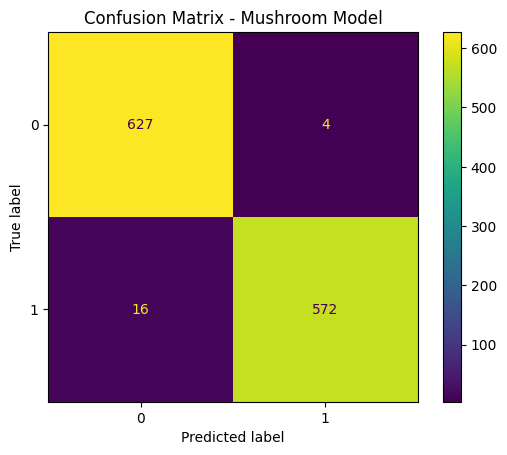

In [ ]:
metrics.ConfusionMatrixDisplay.from_predictions(
    results['target'],
    results['pred']
)

plt.title("Confusion Matrix - Mushroom Model")
plt.show()

The confusion matrix shows that the model correctly classifies the vast majority of mushrooms, with very few errors overall. However, there are more false negatives than false positives, meaning the model occasionally misclassifies poisonous mushrooms as edible, which is the more dangerous type of error in this context.

#### True Positive Rate (Sensitivity / Recall) & False Positive Rate

In [26]:
# TPR (True Positive Rate) = Recall = Sensitivity
# Of all the actually poisonous mushrooms, how many did we correctly flag?
# FPR (False Positive Rate) = how many safe mushrooms did we wrongly accuse?

# Extract values from confusion matrix
# cm format:
# [[TN, FP],
#  [FN, TP]]

tn, fp, fn, tp = cm.ravel()

# TPR (Recall / Sensitivity)
# Of all actual poisonous mushrooms (1), how many did we correctly identify?
tpr = tp / (tp + fn)

# FPR
# Of all edible mushrooms (0), how many did we incorrectly label as poisonous?
fpr = fp / (fp + tn)

print(f"True Positive Rate (TPR / Recall): {tpr:.4f}")
print(f"False Positive Rate (FPR):         {fpr:.4f}")

True Positive Rate (TPR / Recall): 0.9728
False Positive Rate (FPR):         0.0063


#### Classification Report

In [27]:
# Full classification report – the tasting menu of evaluation metrics 
# Shows precision, recall, and F1 score for each class

print(metrics.classification_report(
    results['target'],
    results['pred'],
    target_names=le_target.classes_
))

              precision    recall  f1-score   support

           e       0.98      0.99      0.98       631
           p       0.99      0.97      0.98       588

    accuracy                           0.98      1219
   macro avg       0.98      0.98      0.98      1219
weighted avg       0.98      0.98      0.98      1219



#### ROC Curve & AUC

The ROC curve plots TPR vs FPR at every threshold. AUC (Area Under the Curve) summarises it in one number – 1.0 is perfect, 0.5 is a coin flip.  

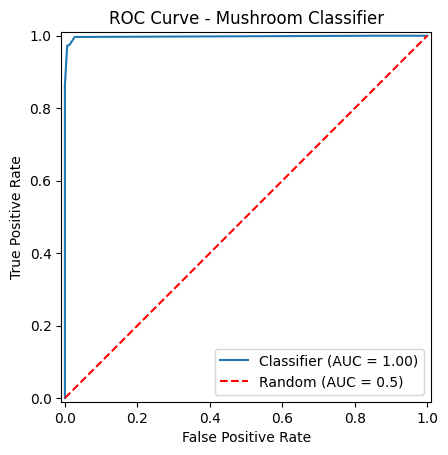

In [28]:
# ROC Curve
# The ROC curve shows the relationship between:
# - True Positive Rate (TPR)
# - False Positive Rate (FPR)
# across different probability thresholds

metrics.RocCurveDisplay.from_predictions(
    results['target'],
    results['prob_poisonous']  # use probability of class "poisonous" (1)
)

# Add reference line for random guessing
plt.plot([0, 1], [0, 1], 'r--', label='Random (AUC = 0.5)')

plt.title("ROC Curve - Mushroom Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### Write a summary of what you found based on the evaluation measures. Include where have you noticed some issues with the model and What metrics do you think we should pay most attention to given the target variable.

 - Do you think we should adjust the threshold from the default value or not? Why or why not?
 -  

Overall, the model performs really well across all the evaluation metrics. The accuracy is around 98%, and the precision, recall, and F1 scores are all very high for both edible and poisonous mushrooms. The ROC curve and AUC score (close to 1) also show that the model is very good at separating the two classes. The fact that training, cross-validation, and tuning results are all similar suggests that the model is not overfitting and generalizes well.

That being said, the confusion matrix shows an important issue. There are more false negatives than false positives, meaning some poisonous mushrooms are being classified as edible. Even though this doesn’t happen often, it’s the most dangerous type of mistake because it could be disastruous. Misclassifying an edible mushroom as poisonous is not ideal, but it’s much safer than the other way around.

Because of this, the most important metric to focus on is recall for poisonous mushrooms. We want to make sure we are catching as many poisonous mushrooms as possible and minimizing false negatives. Metrics like accuracy and AUC are high, but they don’t fully capture how risky those specific errors are.

Based on this, I do think it could make sense to adjust the classification threshold. Lowering the threshold for predicting “poisonous” would help reduce false negatives and improve safety, even if it increases false positives. In this situation, that tradeoff is worth it, because it’s better to be overly cautious than to miss a dangerous mushroom.

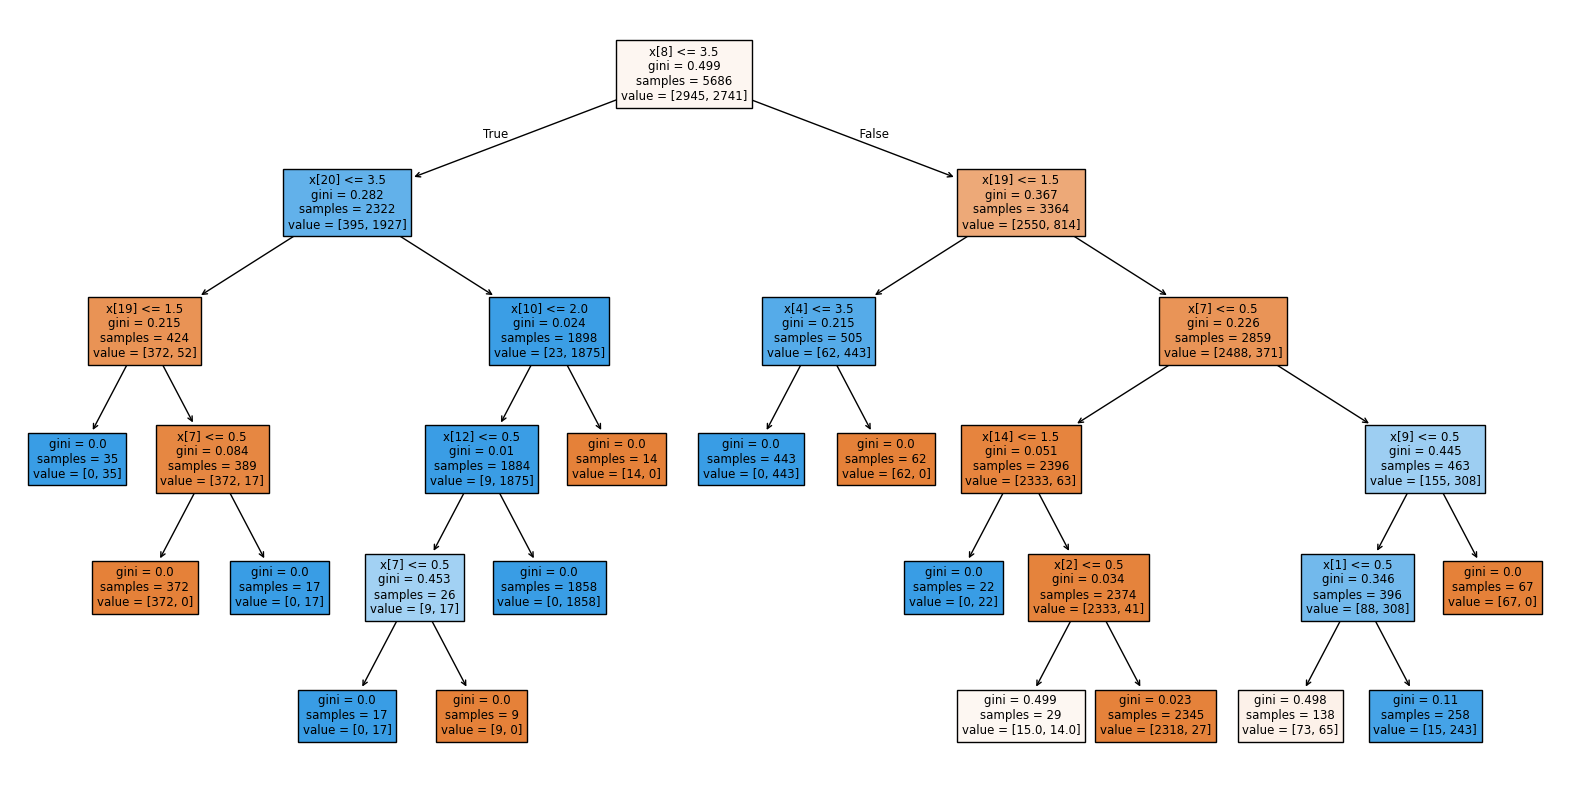

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_pipeline.named_steps['classifier'],  #because using a pipeline we use dt_pipeline.named_steps['classifier'] to access the decision tree inside the pipeline
    filled=True
)

plt.show()

---

You now have a working Decision Tree baseline.

**Attempt the Bonus** 5 points each:

Pick a metric we haven’t covered (e.g., Matthews Correlation Coefficient, Precision-Recall AUC, Cohen’s Kappa) and discuss it.

Choose a model we have not present in class and see if the evaluation is better or worse - be specific about the metric you are using for comparison and why the model seems to fit better or worse. 



In [30]:
# BONUS 1
# Matthews Correlation Coefficient (MCC)
# MCC is a balanced metric that considers all parts of the confusion matrix:
# TP, TN, FP, FN

mcc = metrics.matthews_corrcoef(results['target'], results['pred'])

print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

Matthews Correlation Coefficient (MCC): 0.9673


The Matthews Correlation Coefficient (MCC) is a metric that takes into account all parts of the confusion matrix, including true positives, true negatives, false positives, and false negatives. It is especially useful because it provides a balanced measure of model performance, even when classes are not perfectly balanced. In this case, the MCC score is very close to 1 (0.9673), which indicates that the model is performing extremely well and making very few classification errors.